# CHƯƠNG 5: SPARK MLLIB - MACHINE LEARNING

**Bài toán triển khai:** Phân loại mức độ hài lòng của khách hàng trên bộ dữ liệu Brazilian E-Commerce Public Dataset by Olist.

Quy ước nhãn:

- `review_score >= 4` → `label = 1.0` → khách hàng hài lòng.
- `review_score < 4` → `label = 0.0` → khách hàng chưa hài lòng.

Notebook này được tổ chức theo đúng flow của Chương 5:

1. Bài toán đề xuất.
2. Tiền xử lý dữ liệu.
3. Pipeline MLlib.
4. Huấn luyện mô hình.
5. Đánh giá mô hình.
6. Nhận xét mô hình và thống kê hỗ trợ diễn giải.

Notebook sử dụng đường dẫn HDFS mặc định `hdfs://localhost:9000/Olist`, đồng nhất với source code nạp dữ liệu của nhóm. Nếu chạy bằng file local, đổi `USE_HDFS = False` và chỉnh `LOCAL_BASE_PATH`.

## 5.1. Bài toán đề xuất

Mục tiêu của phần MLlib là xây dựng mô hình phân loại nhị phân để dự đoán khả năng một đơn hàng nhận review tốt hay chưa tốt. Dữ liệu huấn luyện được tạo ở cấp độ `order_id`, kết hợp thông tin từ các bảng `orders`, `customers`, `order_items`, `payments`, `reviews`, `products`, `sellers` và `product_category_name_translation`.

In [1]:
# ============================================================
# 5.1. KHỞI TẠO MÔI TRƯỜNG VÀ NẠP THƯ VIỆN
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Imputer,
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

import os
import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("Chapter5_Olist_Spark_MLlib")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark.conf.set("spark.sql.debug.maxToStringFields", "300")
spark.conf.set("spark.sql.shuffle.partitions", "8")

RANDOM_SEED = 42

USE_HDFS = True
HDFS_BASE_PATH = "hdfs://localhost:9000/Olist"
LOCAL_BASE_PATH = "resources/olist"
BASE_PATH = HDFS_BASE_PATH if USE_HDFS else LOCAL_BASE_PATH

OUTPUT_DIR = "outputs/chapter5_mllib"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("BASE_PATH:", BASE_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_PATH: hdfs://localhost:9000/Olist
OUTPUT_DIR: outputs/chapter5_mllib


In [2]:
# ============================================================
# 5.1.1. ĐỌC 9 FILE DATASET OLIST TỪ HDFS / LOCAL
# ============================================================

customers = spark.read.csv(f"{BASE_PATH}/olist_customers_dataset.csv", header=True, inferSchema=True)
geolocation = spark.read.csv(f"{BASE_PATH}/olist_geolocation_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv(f"{BASE_PATH}/olist_order_items_dataset.csv", header=True, inferSchema=True)
payments = spark.read.csv(f"{BASE_PATH}/olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews = spark.read.csv(f"{BASE_PATH}/olist_order_reviews_dataset.csv", header=True, inferSchema=True)
orders = spark.read.csv(f"{BASE_PATH}/olist_orders_dataset.csv", header=True, inferSchema=True)
products = spark.read.csv(f"{BASE_PATH}/olist_products_dataset.csv", header=True, inferSchema=True)
sellers = spark.read.csv(f"{BASE_PATH}/olist_sellers_dataset.csv", header=True, inferSchema=True)
translation = spark.read.csv(f"{BASE_PATH}/product_category_name_translation.csv", header=True, inferSchema=True)

input_tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation
}

for table_name, df in input_tables.items():
    df.createOrReplaceTempView(table_name)

print("===== KIỂM TRA SỐ DÒNG VÀ SỐ CỘT CÁC BẢNG ĐẦU VÀO =====")
for table_name, df in input_tables.items():
    print(table_name, "| rows =", df.count(), "| columns =", len(df.columns))

===== KIỂM TRA SỐ DÒNG VÀ SỐ CỘT CÁC BẢNG ĐẦU VÀO =====
customers | rows = 99441 | columns = 5
geolocation | rows = 1000163 | columns = 5
order_items | rows = 112650 | columns = 7
payments | rows = 103886 | columns = 5
reviews | rows = 104162 | columns = 7
orders | rows = 99441 | columns = 8
products | rows = 32951 | columns = 9
sellers | rows = 3095 | columns = 4
translation | rows = 71 | columns = 2


## 5.2. Tiền xử lý dữ liệu

Dữ liệu Olist được tổ chức dưới dạng nhiều bảng quan hệ. Đối với bài toán MLlib, nhóm tạo bảng huấn luyện ở cấp độ đơn hàng. Vì một `order_id` có thể có nhiều sản phẩm hoặc nhiều dòng thanh toán, các bảng `order_items` và `payments` cần được tổng hợp trước khi join với bảng `orders` và `reviews`.

In [3]:
# ============================================================
# 5.2.1. CHUẨN HÓA KIỂU DỮ LIỆU
# ============================================================

orders_typed = (
    orders
    .withColumn("order_purchase_timestamp", F.to_timestamp("order_purchase_timestamp"))
    .withColumn("order_approved_at", F.to_timestamp("order_approved_at"))
    .withColumn("order_delivered_carrier_date", F.to_timestamp("order_delivered_carrier_date"))
    .withColumn("order_delivered_customer_date", F.to_timestamp("order_delivered_customer_date"))
    .withColumn("order_estimated_delivery_date", F.to_timestamp("order_estimated_delivery_date"))
)

reviews_typed = (
    reviews
    .withColumn("review_score", F.col("review_score").cast("double"))
    .withColumn("review_creation_date", F.to_timestamp("review_creation_date"))
    .withColumn("review_answer_timestamp", F.to_timestamp("review_answer_timestamp"))
)

payments_typed = (
    payments
    .withColumn("payment_sequential", F.col("payment_sequential").cast("int"))
    .withColumn("payment_installments", F.col("payment_installments").cast("int"))
    .withColumn("payment_value", F.col("payment_value").cast("double"))
)

order_items_typed = (
    order_items
    .withColumn("order_item_id", F.col("order_item_id").cast("int"))
    .withColumn("shipping_limit_date", F.to_timestamp("shipping_limit_date"))
    .withColumn("price", F.col("price").cast("double"))
    .withColumn("freight_value", F.col("freight_value").cast("double"))
)

products_typed = (
    products
    .withColumn("product_name_lenght", F.col("product_name_lenght").cast("double"))
    .withColumn("product_description_lenght", F.col("product_description_lenght").cast("double"))
    .withColumn("product_photos_qty", F.col("product_photos_qty").cast("double"))
    .withColumn("product_weight_g", F.col("product_weight_g").cast("double"))
    .withColumn("product_length_cm", F.col("product_length_cm").cast("double"))
    .withColumn("product_height_cm", F.col("product_height_cm").cast("double"))
    .withColumn("product_width_cm", F.col("product_width_cm").cast("double"))
)

print("===== SCHEMA BẢNG ORDERS SAU CHUẨN HÓA =====")
orders_typed.printSchema()

print("===== SCHEMA BẢNG REVIEWS SAU CHUẨN HÓA =====")
reviews_typed.printSchema()

===== SCHEMA BẢNG ORDERS SAU CHUẨN HÓA =====
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)

===== SCHEMA BẢNG REVIEWS SAU CHUẨN HÓA =====
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: timestamp (nullable = true)
 |-- review_answer_timestamp: timestamp (nullable = true)



In [4]:
# ============================================================
# 5.2.2. TỔNG HỢP THANH TOÁN THEO ORDER_ID
# ============================================================

payments_agg = (
    payments_typed
    .groupBy("order_id")
    .agg(
        F.sum("payment_value").alias("payment_value_total"),
        F.avg("payment_value").alias("payment_value_avg"),
        F.max("payment_installments").alias("payment_installments_max"),
        F.count("*").alias("payment_count"),
        F.first("payment_type", ignorenulls=True).alias("payment_type")
    )
)

print("===== THÔNG TIN THANH TOÁN SAU KHI TỔNG HỢP =====")
payments_agg.show(10, truncate=False)

===== THÔNG TIN THANH TOÁN SAU KHI TỔNG HỢP =====
+--------------------------------+-------------------+-----------------+------------------------+-------------+------------+
|order_id                        |payment_value_total|payment_value_avg|payment_installments_max|payment_count|payment_type|
+--------------------------------+-------------------+-----------------+------------------------+-------------+------------+
|000229ec398224ef6ca0657da4fc703e|216.87             |216.87           |5                       |1            |credit_card |
|00042b26cf59d7ce69dfabb4e55b4fd9|218.04             |218.04           |3                       |1            |credit_card |
|0005f50442cb953dcd1d21e1fb923495|65.39              |65.39            |1                       |1            |credit_card |
|00061f2a7bc09da83e415a52dc8a4af1|68.87              |68.87            |3                       |1            |credit_card |
|00063b381e2406b52ad429470734ebd5|57.98              |57.98            |5  

In [5]:
# ============================================================
# 5.2.3. TỔNG HỢP SẢN PHẨM, SELLER VÀ DANH MỤC THEO ORDER_ID
# ============================================================

items_enriched = (
    order_items_typed
    .join(products_typed, on="product_id", how="left")
    .join(translation, on="product_category_name", how="left")
    .join(sellers, on="seller_id", how="left")
    .withColumn(
        "product_volume_cm3",
        F.col("product_length_cm") * F.col("product_height_cm") * F.col("product_width_cm")
    )
)

items_agg = (
    items_enriched
    .groupBy("order_id")
    .agg(
        F.count("*").alias("item_count"),
        F.countDistinct("product_id").alias("distinct_product_count"),
        F.countDistinct("seller_id").alias("distinct_seller_count"),
        F.sum("price").alias("price_total"),
        F.avg("price").alias("price_avg"),
        F.sum("freight_value").alias("freight_value_total"),
        F.avg("freight_value").alias("freight_value_avg"),
        F.avg("product_name_lenght").alias("product_name_lenght_avg"),
        F.avg("product_description_lenght").alias("product_description_lenght_avg"),
        F.avg("product_photos_qty").alias("product_photos_qty_avg"),
        F.avg("product_weight_g").alias("product_weight_g_avg"),
        F.avg("product_volume_cm3").alias("product_volume_cm3_avg"),
        F.first("product_category_name_english", ignorenulls=True).alias("product_category_name_english"),
        F.first("seller_state", ignorenulls=True).alias("seller_state")
    )
    .withColumn(
        "freight_ratio",
        F.when(F.col("price_total") > 0, F.col("freight_value_total") / F.col("price_total"))
         .otherwise(None)
    )
)

print("===== THÔNG TIN SẢN PHẨM/SELLER SAU KHI TỔNG HỢP =====")
items_agg.show(10, truncate=False)

===== THÔNG TIN SẢN PHẨM/SELLER SAU KHI TỔNG HỢP =====
+--------------------------------+----------+----------------------+---------------------+-----------+---------+-------------------+-----------------+-----------------------+------------------------------+----------------------+--------------------+----------------------+-----------------------------+------------+-------------------+
|order_id                        |item_count|distinct_product_count|distinct_seller_count|price_total|price_avg|freight_value_total|freight_value_avg|product_name_lenght_avg|product_description_lenght_avg|product_photos_qty_avg|product_weight_g_avg|product_volume_cm3_avg|product_category_name_english|seller_state|freight_ratio      |
+--------------------------------+----------+----------------------+---------------------+-----------+---------+-------------------+-----------------+-----------------------+------------------------------+----------------------+--------------------+----------------------+-

In [6]:
# ============================================================
# 5.2.4. TỔNG HỢP REVIEW THEO ORDER_ID VÀ XEM PHÂN BỐ REVIEW_SCORE
# ============================================================

reviews_agg = (
    reviews_typed
    .groupBy("order_id")
    .agg(F.avg("review_score").alias("review_score"))
)

print("===== PHÂN BỐ REVIEW_SCORE TRƯỚC KHI TẠO NHÃN =====")
reviews_agg.groupBy("review_score").count().orderBy("review_score").show()

===== PHÂN BỐ REVIEW_SCORE TRƯỚC KHI TẠO NHÃN =====
+------------------+-----+
|      review_score|count|
+------------------+-----+
|              NULL| 1067|
|               0.0|    2|
|               1.0|11316|
|               1.5|    8|
|               2.0| 3125|
|               2.5|   34|
|               3.0| 8136|
|3.3333333333333335|    1|
|               3.5|   25|
|               4.0|19018|
| 4.333333333333333|    1|
|               4.5|   54|
|               5.0|56955|
|              90.0|    1|
+------------------+-----+



In [7]:
# ============================================================
# 5.2.5. TẠO BẢNG DỮ LIỆU HUẤN LUYỆN Ở CẤP ĐỘ ORDER_ID
# ============================================================

ml_base = (
    orders_typed.alias("o")
    .join(customers.alias("c"), on="customer_id", how="left")
    .join(payments_agg.alias("p"), on="order_id", how="left")
    .join(items_agg.alias("i"), on="order_id", how="left")
    .join(reviews_agg.alias("r"), on="order_id", how="inner")
)

ml_base = (
    ml_base
    .withColumn("delivery_days", F.datediff(F.col("order_delivered_customer_date"), F.col("order_purchase_timestamp")).cast("double"))
    .withColumn("estimated_delivery_days", F.datediff(F.col("order_estimated_delivery_date"), F.col("order_purchase_timestamp")).cast("double"))
    .withColumn("delivery_delay_days", F.datediff(F.col("order_delivered_customer_date"), F.col("order_estimated_delivery_date")).cast("double"))
    .withColumn("approval_hours", (F.unix_timestamp("order_approved_at") - F.unix_timestamp("order_purchase_timestamp")) / 3600)
    .withColumn(
        "is_late_delivery",
        F.when(F.col("order_delivered_customer_date").isNull() | F.col("order_estimated_delivery_date").isNull(), None)
         .when(F.col("order_delivered_customer_date") > F.col("order_estimated_delivery_date"), F.lit(1.0))
         .otherwise(F.lit(0.0))
    )
    .withColumn("has_delivery_info", F.when(F.col("order_delivered_customer_date").isNull(), F.lit(0.0)).otherwise(F.lit(1.0)))
    .withColumn("purchase_year", F.year("order_purchase_timestamp").cast("double"))
    .withColumn("purchase_month", F.month("order_purchase_timestamp").cast("double"))
    .withColumn("purchase_dayofweek", F.dayofweek("order_purchase_timestamp").cast("double"))
    .withColumn("same_customer_seller_state", F.when(F.col("customer_state") == F.col("seller_state"), F.lit(1.0)).otherwise(F.lit(0.0)))
    .withColumn("label", F.when(F.col("review_score") >= 4, F.lit(1.0)).otherwise(F.lit(0.0)))
)

numeric_cols = [
    "payment_value_total",
    "payment_value_avg",
    "payment_installments_max",
    "payment_count",
    "item_count",
    "distinct_product_count",
    "distinct_seller_count",
    "price_total",
    "price_avg",
    "freight_value_total",
    "freight_value_avg",
    "freight_ratio",
    "product_name_lenght_avg",
    "product_description_lenght_avg",
    "product_photos_qty_avg",
    "product_weight_g_avg",
    "product_volume_cm3_avg",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "approval_hours",
    "is_late_delivery",
    "has_delivery_info",
    "same_customer_seller_state",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek"
]

categorical_cols = [
    "order_status",
    "payment_type",
    "customer_state",
    "seller_state",
    "product_category_name_english"
]

selected_cols = ["order_id", "review_score", "label"] + numeric_cols + categorical_cols
ml_data = ml_base.select(selected_cols)

for c in categorical_cols:
    ml_data = ml_data.withColumn(
        c,
        F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), F.lit("Unknown"))
         .otherwise(F.col(c))
    )

for c in numeric_cols:
    ml_data = ml_data.withColumn(c, F.col(c).cast("double"))

ml_data = ml_data.dropna(subset=["label"]).cache()

print("===== BẢNG DỮ LIỆU HUẤN LUYỆN MLLIB =====")
print("Số dòng:", ml_data.count())
print("Số cột:", len(ml_data.columns))
ml_data.printSchema()

print("===== 10 DÒNG ĐẦU CỦA BẢNG MLLIB =====")
ml_data.show(10, truncate=False)

===== BẢNG DỮ LIỆU HUẤN LUYỆN MLLIB =====
Số dòng: 98673
Số cột: 35
root
 |-- order_id: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- label: double (nullable = false)
 |-- payment_value_total: double (nullable = true)
 |-- payment_value_avg: double (nullable = true)
 |-- payment_installments_max: double (nullable = true)
 |-- payment_count: double (nullable = true)
 |-- item_count: double (nullable = true)
 |-- distinct_product_count: double (nullable = true)
 |-- distinct_seller_count: double (nullable = true)
 |-- price_total: double (nullable = true)
 |-- price_avg: double (nullable = true)
 |-- freight_value_total: double (nullable = true)
 |-- freight_value_avg: double (nullable = true)
 |-- freight_ratio: double (nullable = true)
 |-- product_name_lenght_avg: double (nullable = true)
 |-- product_description_lenght_avg: double (nullable = true)
 |-- product_photos_qty_avg: double (nullable = true)
 |-- product_weight_g_avg: double (nullable = true)
 |-

===== KIỂM TRA GIÁ TRỊ THIẾU TRONG BẢNG MLLIB =====
+--------+------------+-----+-------------------+-----------------+------------------------+-------------+----------+----------------------+---------------------+-----------+---------+-------------------+-----------------+-------------+-----------------------+------------------------------+----------------------+--------------------+----------------------+-------------+-----------------------+-------------------+--------------+----------------+-----------------+--------------------------+-------------+--------------+------------------+------------+------------+--------------+------------+-----------------------------+
|order_id|review_score|label|payment_value_total|payment_value_avg|payment_installments_max|payment_count|item_count|distinct_product_count|distinct_seller_count|price_total|price_avg|freight_value_total|freight_value_avg|freight_ratio|product_name_lenght_avg|product_description_lenght_avg|product_photos_qty_avg|product_

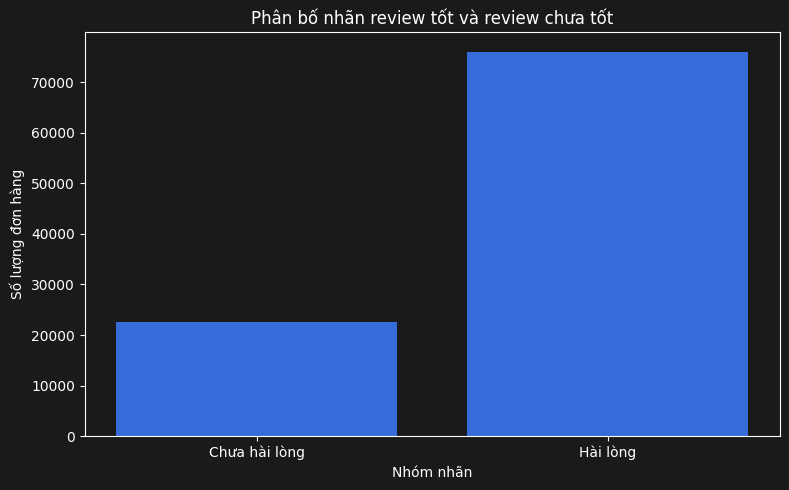

In [8]:
# ============================================================
# 5.2.6. KIỂM TRA MISSING VALUES VÀ PHÂN BỐ NHÃN
# ============================================================

print("===== KIỂM TRA GIÁ TRỊ THIẾU TRONG BẢNG MLLIB =====")
missing_summary = ml_data.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ml_data.columns
])
missing_summary.show(truncate=False)

print("===== PHÂN BỐ NHÃN LABEL =====")
label_distribution = (
    ml_data
    .groupBy("label")
    .agg(F.count("*").alias("count"))
    .withColumn("percentage", F.round(F.col("count") * 100 / ml_data.count(), 2))
    .orderBy("label")
)
label_distribution.show(truncate=False)

label_pdf = label_distribution.toPandas()
label_pdf["label_name"] = label_pdf["label"].map({0.0: "Chưa hài lòng", 1.0: "Hài lòng"})

plt.figure(figsize=(8, 5))
plt.bar(label_pdf["label_name"], label_pdf["count"])
plt.title("Phân bố nhãn review tốt và review chưa tốt")
plt.xlabel("Nhóm nhãn")
plt.ylabel("Số lượng đơn hàng")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/label_distribution.png", dpi=150)
plt.show()

## 5.3. Pipeline MLlib

Pipeline gồm các bước: `Imputer` → `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `StandardScaler` → mô hình phân loại. Cách tổ chức này giúp toàn bộ bước tiền xử lý được fit trên tập train và áp dụng nhất quán lên tập test.

In [9]:
# ============================================================
# 5.3. XÂY DỰNG PIPELINE MLLIB
# ============================================================

numeric_imputed_cols = [c + "_imputed" for c in numeric_cols]

imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=numeric_imputed_cols
).setStrategy("median")

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_index",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

encoded_cols = [c + "_encoded" for c in categorical_cols]

encoder = OneHotEncoder(
    inputCols=[c + "_index" for c in categorical_cols],
    outputCols=encoded_cols,
    dropLast=False
)

assembler = VectorAssembler(
    inputCols=numeric_imputed_cols + encoded_cols,
    outputCol="raw_features",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=False
)

preprocess_stages = [imputer] + indexers + [encoder, assembler, scaler]

print("===== CÁC CỘT SỐ ĐƯỢC SỬ DỤNG =====")
for c in numeric_cols:
    print("-", c)

print("===== CÁC CỘT PHÂN LOẠI ĐƯỢC SỬ DỤNG =====")
for c in categorical_cols:
    print("-", c)

print("===== CÁC BƯỚC TRONG PIPELINE TIỀN XỬ LÝ =====")
for stage in preprocess_stages:
    print("-", stage.__class__.__name__)

===== CÁC CỘT SỐ ĐƯỢC SỬ DỤNG =====
- payment_value_total
- payment_value_avg
- payment_installments_max
- payment_count
- item_count
- distinct_product_count
- distinct_seller_count
- price_total
- price_avg
- freight_value_total
- freight_value_avg
- freight_ratio
- product_name_lenght_avg
- product_description_lenght_avg
- product_photos_qty_avg
- product_weight_g_avg
- product_volume_cm3_avg
- delivery_days
- estimated_delivery_days
- delivery_delay_days
- approval_hours
- is_late_delivery
- has_delivery_info
- same_customer_seller_state
- purchase_year
- purchase_month
- purchase_dayofweek
===== CÁC CỘT PHÂN LOẠI ĐƯỢC SỬ DỤNG =====
- order_status
- payment_type
- customer_state
- seller_state
- product_category_name_english
===== CÁC BƯỚC TRONG PIPELINE TIỀN XỬ LÝ =====
- Imputer
- StringIndexer
- StringIndexer
- StringIndexer
- StringIndexer
- StringIndexer
- OneHotEncoder
- VectorAssembler
- StandardScaler


## 5.4. Huấn luyện mô hình

Dữ liệu được chia theo tỷ lệ 80/20. Trọng số lớp (`class_weight`) được tính từ tập train để giảm ảnh hưởng của mất cân bằng nhãn. Notebook thử nghiệm bốn mô hình: Logistic Regression, Decision Tree, Random Forest và Gradient Boosted Tree.

In [10]:
# ============================================================
# 5.4. CHIA TRAIN/TEST VÀ TÍNH CLASS WEIGHT
# ============================================================

train_data_raw, test_data_raw = ml_data.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
train_data_raw.cache()
test_data_raw.cache()

train_count = train_data_raw.count()
test_count = test_data_raw.count()

print("Số dòng train:", train_count)
print("Số dòng test :", test_count)

print("===== PHÂN BỐ NHÃN TRÊN TẬP TRAIN =====")
train_data_raw.groupBy("label").count().orderBy("label").show()

print("===== PHÂN BỐ NHÃN TRÊN TẬP TEST =====")
test_data_raw.groupBy("label").count().orderBy("label").show()

label_counts_train = train_data_raw.groupBy("label").count()
num_classes = label_counts_train.count()

class_weights = (
    label_counts_train
    .withColumn("class_weight", F.lit(float(train_count)) / (F.lit(float(num_classes)) * F.col("count")))
    .select("label", "class_weight")
)

print("===== CLASS WEIGHT TÍNH TRÊN TẬP TRAIN =====")
class_weights.show()

train_data = train_data_raw.join(class_weights, on="label", how="left")
test_data = test_data_raw.join(class_weights, on="label", how="left")

Số dòng train: 79160
Số dòng test : 19513
===== PHÂN BỐ NHÃN TRÊN TẬP TRAIN =====
+-----+-----+
|label|count|
+-----+-----+
|  0.0|18202|
|  1.0|60958|
+-----+-----+

===== PHÂN BỐ NHÃN TRÊN TẬP TEST =====
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 4443|
|  1.0|15070|
+-----+-----+

===== CLASS WEIGHT TÍNH TRÊN TẬP TRAIN =====
+-----+------------------+
|label|      class_weight|
+-----+------------------+
|  1.0|0.6492995177007119|
|  0.0| 2.174486320184595|
+-----+------------------+



In [11]:
# ============================================================
# 5.4.1. KHAI BÁO MÔ HÌNH VÀ EVALUATOR
# ============================================================

models = [
    (
        "Logistic Regression",
        LogisticRegression(
            featuresCol="features",
            labelCol="label",
            weightCol="class_weight",
            predictionCol="prediction",
            probabilityCol="probability",
            rawPredictionCol="rawPrediction",
            maxIter=60,
            regParam=0.05,
            elasticNetParam=0.0
        )
    ),
    (
        "Decision Tree Classifier",
        DecisionTreeClassifier(
            featuresCol="features",
            labelCol="label",
            weightCol="class_weight",
            predictionCol="prediction",
            probabilityCol="probability",
            rawPredictionCol="rawPrediction",
            maxDepth=8,
            seed=RANDOM_SEED
        )
    ),
    (
        "Random Forest Classifier",
        RandomForestClassifier(
            featuresCol="features",
            labelCol="label",
            weightCol="class_weight",
            predictionCol="prediction",
            probabilityCol="probability",
            rawPredictionCol="rawPrediction",
            numTrees=50,
            maxDepth=8,
            seed=RANDOM_SEED
        )
    ),
    (
        "Gradient Boosted Tree Classifier",
        GBTClassifier(
            featuresCol="features",
            labelCol="label",
            weightCol="class_weight",
            predictionCol="prediction",
            maxIter=30,
            maxDepth=5,
            seed=RANDOM_SEED
        )
    )
]

accuracy_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
auc_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

## 5.5. Đánh giá mô hình

In [ ]:
# ============================================================
# 5.5. HUẤN LUYỆN VÀ ĐÁNH GIÁ TỪNG MÔ HÌNH
# ============================================================

model_results = []
fitted_models = {}
predictions_by_model = {}

for model_name, classifier in models:
    print("\n" + "=" * 100)
    print("ĐANG HUẤN LUYỆN MÔ HÌNH:", model_name)
    print("=" * 100)

    pipeline = Pipeline(stages=preprocess_stages + [classifier])
    pipeline_model = pipeline.fit(train_data)
    predictions = pipeline_model.transform(test_data)
    predictions.cache()

    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    auc = auc_evaluator.evaluate(predictions)

    model_results.append({
        "model": model_name,
        "accuracy": float(accuracy),
        "f1_score": float(f1),
        "weighted_precision": float(precision),
        "weighted_recall": float(recall),
        "roc_auc": float(auc)
    })

    fitted_models[model_name] = pipeline_model
    predictions_by_model[model_name] = predictions

    print("Accuracy          :", round(accuracy, 4))
    print("F1-score          :", round(f1, 4))
    print("Weighted Precision:", round(precision, 4))
    print("Weighted Recall   :", round(recall, 4))
    print("ROC-AUC           :", round(auc, 4))

    print("\nMa trận nhầm lẫn:")
    predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

    print("\nMột số dòng dự đoán:")
    predictions.select(
        "order_id",
        "review_score",
        "label",
        "prediction",
        "payment_value_total",
        "delivery_days",
        "delivery_delay_days",
        "is_late_delivery",
        "payment_type",
        "customer_state",
        "product_category_name_english"
    ).show(10, truncate=False)


ĐANG HUẤN LUYỆN MÔ HÌNH: Logistic Regression
Accuracy          : 0.7751
F1-score          : 0.7759
Weighted Precision: 0.7766
Weighted Recall   : 0.7751
ROC-AUC           : 0.7353

Ma trận nhầm lẫn:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 2291|
|  0.0|       1.0| 2152|
|  1.0|       0.0| 2236|
|  1.0|       1.0|12834|
+-----+----------+-----+


Một số dòng dự đoán:
+--------------------------------+------------+-----+----------+-------------------+-------------+-------------------+----------------+------------+--------------+-----------------------------+
|order_id                        |review_score|label|prediction|payment_value_total|delivery_days|delivery_delay_days|is_late_delivery|payment_type|customer_state|product_category_name_english|
+--------------------------------+------------+-----+----------+-------------------+-------------+-------------------+----------------+------------+--------------+--------------------------

## 5.6. So sánh mô hình

Phần này tổng hợp chỉ số đánh giá của các mô hình, chọn mô hình tốt nhất theo F1-score và ROC-AUC, đồng thời lưu các bảng/ảnh minh chứng ra thư mục `outputs/chapter5_mllib`.

===== BẢNG SO SÁNH CÁC MÔ HÌNH =====
                              model  accuracy  f1_score  weighted_precision  \
2          Random Forest Classifier  0.794547  0.789244            0.785614   
0               Logistic Regression  0.775124  0.775863            0.776632   
3  Gradient Boosted Tree Classifier  0.773536  0.775246            0.777124   
1          Decision Tree Classifier  0.774817  0.773741            0.772726   

   weighted_recall   roc_auc  
2         0.794547  0.730261  
0         0.775124  0.735309  
3         0.773536  0.740335  
1         0.774817  0.707299  
===== MÔ HÌNH TỐT NHẤT =====
Best model: Random Forest Classifier
model                 Random Forest Classifier
accuracy                              0.794547
f1_score                              0.789244
weighted_precision                    0.785614
weighted_recall                       0.794547
roc_auc                               0.730261
Name: 2, dtype: object


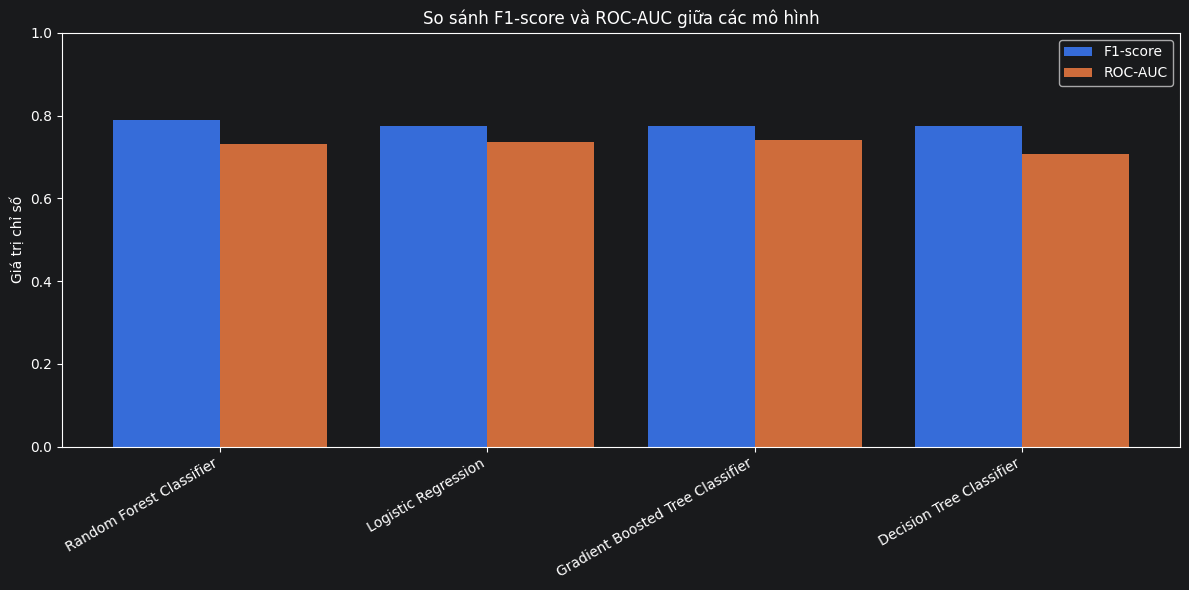

In [ ]:
# ============================================================
# 5.6. TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ VÀ CHỌN MÔ HÌNH TỐT NHẤT
# ============================================================

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by=["f1_score", "roc_auc"], ascending=False)

print("===== BẢNG SO SÁNH CÁC MÔ HÌNH =====")
print(results_df)

results_df.to_csv(f"{OUTPUT_DIR}/model_metrics.csv", index=False, encoding="utf-8-sig")

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]

print("===== MÔ HÌNH TỐT NHẤT =====")
print("Best model:", best_model_name)
print(results_df.iloc[0])

plt.figure(figsize=(12, 6))
x = range(len(results_df))
plt.bar([i - 0.2 for i in x], results_df["f1_score"], width=0.4, label="F1-score")
plt.bar([i + 0.2 for i in x], results_df["roc_auc"], width=0.4, label="ROC-AUC")
plt.xticks(list(x), results_df["model"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("So sánh F1-score và ROC-AUC giữa các mô hình")
plt.ylabel("Giá trị chỉ số")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison_f1_auc.png", dpi=150)
plt.show()

===== MỘT SỐ DÒNG DỰ ĐOÁN CỦA MÔ HÌNH TỐT NHẤT =====
+--------------------------------+------------+-----+----------+-------------------+-----------+-------------------+-------------+-------------------+----------------+------------+--------------+------------+-----------------------------+
|order_id                        |review_score|label|prediction|payment_value_total|price_total|freight_value_total|delivery_days|delivery_delay_days|is_late_delivery|payment_type|customer_state|seller_state|product_category_name_english|
+--------------------------------+------------+-----+----------+-------------------+-----------+-------------------+-------------+-------------------+----------------+------------+--------------+------------+-----------------------------+
|00063b381e2406b52ad429470734ebd5|5.0         |1.0  |1.0       |57.98              |45.0       |12.98              |11.0         |0.0                |1.0             |credit_card |SP            |SP          |fashion_bags_accessori

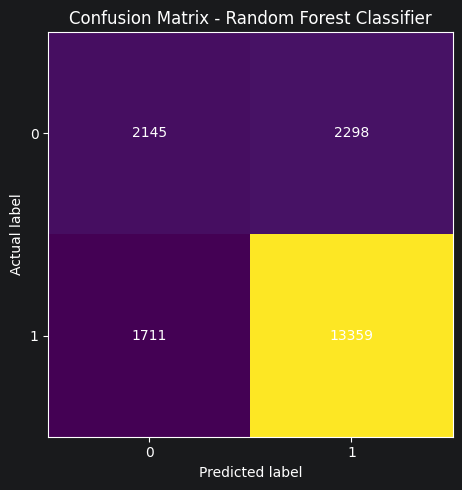

In [ ]:
# ============================================================
# 5.6.1. SAMPLE PREDICTIONS VÀ CONFUSION MATRIX
# ============================================================

print("===== MỘT SỐ DÒNG DỰ ĐOÁN CỦA MÔ HÌNH TỐT NHẤT =====")
sample_predictions = best_predictions.select(
    "order_id",
    "review_score",
    "label",
    "prediction",
    "payment_value_total",
    "price_total",
    "freight_value_total",
    "delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "payment_type",
    "customer_state",
    "seller_state",
    "product_category_name_english"
)
sample_predictions.show(20, truncate=False)
sample_predictions.limit(200).toPandas().to_csv(f"{OUTPUT_DIR}/sample_predictions.csv", index=False, encoding="utf-8-sig")

confusion_matrix = best_predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
print("===== MA TRẬN NHẦM LẪN CỦA MÔ HÌNH TỐT NHẤT =====")
confusion_matrix.show()

confusion_pdf = confusion_matrix.toPandas()
confusion_pdf.to_csv(f"{OUTPUT_DIR}/confusion_matrix.csv", index=False, encoding="utf-8-sig")

confusion_pivot = confusion_pdf.pivot(index="label", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(6, 5))
plt.imshow(confusion_pivot.values)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.xticks(range(len(confusion_pivot.columns)), [str(int(x)) for x in confusion_pivot.columns])
plt.yticks(range(len(confusion_pivot.index)), [str(int(x)) for x in confusion_pivot.index])

for i in range(confusion_pivot.shape[0]):
    for j in range(confusion_pivot.shape[1]):
        plt.text(j, i, int(confusion_pivot.values[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## 5.7. Nhận xét mô hình

Các thống kê dưới đây hỗ trợ diễn giải kết quả dự đoán theo góc nhìn nghiệp vụ: giao hàng trễ, thời gian giao hàng, giá trị đơn hàng và điểm đánh giá trung bình.

In [ ]:
# ============================================================
# 5.7. THỐNG KÊ HỖ TRỢ NHẬN XÉT MÔ HÌNH
# ============================================================

best_predictions.createOrReplaceTempView("best_predictions")

print("===== THỐNG KÊ THEO LABEL VÀ PREDICTION =====")
diagnostic_prediction = spark.sql("""
    SELECT
        label,
        prediction,
        COUNT(*) AS total_orders,
        ROUND(AVG(review_score), 2) AS avg_review_score,
        ROUND(AVG(payment_value_total), 2) AS avg_payment_value,
        ROUND(AVG(price_total), 2) AS avg_price_total,
        ROUND(AVG(freight_value_total), 2) AS avg_freight_value,
        ROUND(AVG(delivery_days), 2) AS avg_delivery_days,
        ROUND(AVG(delivery_delay_days), 2) AS avg_delivery_delay_days,
        ROUND(AVG(is_late_delivery), 4) AS late_delivery_ratio
    FROM best_predictions
    GROUP BY label, prediction
    ORDER BY label, prediction
""")
diagnostic_prediction.show(truncate=False)
diagnostic_prediction.toPandas().to_csv(f"{OUTPUT_DIR}/diagnostic_by_prediction.csv", index=False, encoding="utf-8-sig")

print("===== REVIEW THEO TÌNH TRẠNG GIAO TRỄ =====")
diagnostic_late = spark.sql("""
    SELECT
        is_late_delivery,
        COUNT(*) AS total_orders,
        ROUND(AVG(review_score), 2) AS avg_review_score,
        ROUND(AVG(payment_value_total), 2) AS avg_payment_value,
        ROUND(AVG(delivery_days), 2) AS avg_delivery_days
    FROM best_predictions
    GROUP BY is_late_delivery
    ORDER BY is_late_delivery
""")
diagnostic_late.show(truncate=False)
diagnostic_late.toPandas().to_csv(f"{OUTPUT_DIR}/diagnostic_late_delivery.csv", index=False, encoding="utf-8-sig")

print("===== REVIEW THEO NHÓM THỜI GIAN GIAO HÀNG =====")
diagnostic_delivery_group = spark.sql("""
    SELECT
        CASE
            WHEN delivery_days <= 5 THEN 'Fast'
            WHEN delivery_days <= 10 THEN 'Normal'
            WHEN delivery_days > 10 THEN 'Slow'
            ELSE 'Unknown'
        END AS delivery_group,
        COUNT(*) AS total_orders,
        ROUND(AVG(review_score), 2) AS avg_review_score,
        ROUND(AVG(payment_value_total), 2) AS avg_payment_value,
        ROUND(AVG(freight_value_total), 2) AS avg_freight_value
    FROM best_predictions
    GROUP BY
        CASE
            WHEN delivery_days <= 5 THEN 'Fast'
            WHEN delivery_days <= 10 THEN 'Normal'
            WHEN delivery_days > 10 THEN 'Slow'
            ELSE 'Unknown'
        END
    ORDER BY avg_review_score DESC
""")
diagnostic_delivery_group.show(truncate=False)
diagnostic_delivery_group.toPandas().to_csv(f"{OUTPUT_DIR}/diagnostic_delivery_group.csv", index=False, encoding="utf-8-sig")

===== THỐNG KÊ THEO LABEL VÀ PREDICTION =====
+-----+----------+------------+----------------+-----------------+---------------+-----------------+-----------------+-----------------------+-------------------+
|label|prediction|total_orders|avg_review_score|avg_payment_value|avg_price_total|avg_freight_value|avg_delivery_days|avg_delivery_delay_days|late_delivery_ratio|
+-----+----------+------------+----------------+-----------------+---------------+-----------------+-----------------+-----------------------+-------------------+
|0.0  |0.0       |2145        |1.54            |211.42           |176.66         |32.62            |26.89            |0.95                   |0.6113             |
|0.0  |1.0       |2298        |2.17            |142.12           |121.98         |20.09            |11.18            |-13.38                 |4.0E-4             |
|1.0  |0.0       |1711        |4.68            |228.9            |189.66         |39.97            |18.48            |-8.59                

In [ ]:
# ============================================================
# LƯU MÔ HÌNH TỐT NHẤT VÀ IN DANH SÁCH OUTPUT
# ============================================================

best_model_path = f"{OUTPUT_DIR}/best_pipeline_model"

try:
    best_model.write().overwrite().save(best_model_path)
    print("Đã lưu mô hình tốt nhất tại:", best_model_path)
except Exception as e:
    print("Không lưu được mô hình do lỗi:", str(e))

print("===== DANH SÁCH FILE OUTPUT =====")
for file_name in os.listdir(OUTPUT_DIR):
    print(os.path.join(OUTPUT_DIR, file_name))

Đã lưu mô hình tốt nhất tại: outputs/chapter5_mllib/best_pipeline_model
===== DANH SÁCH FILE OUTPUT =====
outputs/chapter5_mllib\best_pipeline_model
outputs/chapter5_mllib\confusion_matrix.csv
outputs/chapter5_mllib\confusion_matrix.png
outputs/chapter5_mllib\diagnostic_by_prediction.csv
outputs/chapter5_mllib\diagnostic_delivery_group.csv
outputs/chapter5_mllib\diagnostic_late_delivery.csv
outputs/chapter5_mllib\label_distribution.png
outputs/chapter5_mllib\model_comparison_f1_auc.png
outputs/chapter5_mllib\model_metrics.csv
outputs/chapter5_mllib\sample_predictions.csv
